In [1]:
import pandas as pd
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt
import mplhep as hep
fontsize = 16
plt.style.use([hep.style.ROOT, {'font.size': fontsize}])
#from matplotlib import colors
from matplotlib.offsetbox import AnchoredText
from pocket_coffea.parameters.lumi import lumi, femtobarn

In [2]:
year = "2016_PreVFP"
basedir = f"/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/{year}"

In [3]:
os.listdir(basedir)

['output_all_templates_3f_tau21p20_renormalized.pkl',
 'output_all_templates_3f_tau21p30.pkl',
 'output_all_templates_3f_tau21p35_renormalized.pkl',
 'output_all_templates_5f_inclusive.pkl',
 'output_all_templates_3f_inclusive_fit_variable_reweighed.pkl',
 'output_all_templates_3f_tau21p40_renormalized.pkl',
 'output_all_templates_5f_tau21p40.pkl',
 'output_all_templates_5f_tau21p35.pkl',
 'output_all_templates_5f_inclusive_fit_variable_reweighed.pkl',
 'output_all_templates_3f_tau21p25_renormalized.pkl',
 'output_all_templates_3f_tau21p30_renormalized.pkl',
 'output_all_templates_5f_tau21p25.pkl',
 'output_all_templates_3f_tau21p30_fit_variable_reweighed.pkl',
 'output_all_templates_3f_tau21p20.pkl',
 'output_all_templates_5f_tau21p30.pkl',
 'output_all.coffea',
 'output_all_templates_5f_tau21p40_renormalized.pkl',
 'logs',
 'fit_tau21p40_all_renormalized',
 'output_all_templates_5f_tau21p30_fit_variable_reweighed.pkl',
 'output_all_templates_3f_tau21p40.pkl',
 'fit_tau21p35_all_renor

In [4]:
tau_inclusive = f"{basedir}/fit_inclusive_all_renormalized/results"
tau_cut = f"{basedir}/fit_tau21p%1_all_renormalized/results"
tau_p30_reweighed = f"{basedir}/fit_tau21p30_all_fit_variable_reweighed/results"

In [5]:
AK8Taggers_bb = ['btagDDBvLV2', 'particleNetMD_Xbb_QCD', 'deepTagMD_ZHbbvsQCD', 'btagHbb']
AK8Taggers_cc = ['btagDDCvLV2', 'particleNetMD_Xcc_QCD', 'deepTagMD_ZHccvsQCD']
#tau21s = ["0.20", "0.25","0.30", "0.35", "0.40"]
tau21s = ["0.40", "0.35","0.30", "0.25", "0.20"]
wps  = [ "L","M","H"]
pts = ["450to500","500to600", "600toInf"]
colors = ["green", "red", "blue"]
offset = {
    'L' : +0.1,
    'M' : 0,
    'H' : -0.1,
}

In [6]:
results = []
missing_fits = []

In [7]:
for tagger in AK8Taggers_cc:
    for wp in wps:
        for pt in pts:
            file = f"{tau_inclusive}/fitResults_msd40{tagger}{wp}wp_Pt-{pt}.csv"
            if not os.path.exists(file):
                missing_fits.append(file)
                continue
            #print(file)
            df = pd.read_csv(file, sep=",")
            results.append({
                            "SF_flavour": "c",
                            "tagger": tagger,
                            "wp": wp,
                            "pt": pt,
                            "SF": df["c+cc"].values[0],
                            "SF_errUp": df["c+ccErrUp"].values[0],
                            "SF_errDown": df["c+ccErrDown"].values[0],
                            "tau21": 1,
                            "reweighed": 0
                            })
#loop on tau21
for tagger in AK8Taggers_cc:
    for wp in wps:
        for pt in pts:
            for tau21 in tau21s:
                file = f"{tau_cut.replace('%1', tau21[2:])}/fitResults_msd40{tagger}{wp}wp_Pt-{pt}.csv"
                if not os.path.exists(file):
                    missing_fits.append(file)
                    continue
                #print(file)
                df = pd.read_csv(file, sep=",")
                results.append({
                                "SF_flavour": "c",
                                "tagger": tagger,
                                "wp": wp,
                                "pt": pt,
                                "SF": df["c+cc"].values[0],
                                "SF_errUp": df["c+ccErrUp"].values[0],
                                "SF_errDown": df["c+ccErrDown"].values[0],
                                "tau21": tau21,
                                "reweighed": 0
                                })

for tagger in AK8Taggers_cc:
    for wp in wps:
        for pt in pts:
            file = f"{tau_p30_reweighed}/fitResults_msd40{tagger}{wp}wp_Pt-{pt}.csv"
            if not os.path.exists(file):
                missing_fits.append(file)
                continue
            #print(file)
            df = pd.read_csv(file, sep=",")
            results.append({
                            "SF_flavour": "c",
                            "tagger": tagger,
                            "wp": wp,
                            "pt": pt,
                            "SF": df["c+cc"].values[0],
                            "SF_errUp": df["c+ccErrUp"].values[0],
                            "SF_errDown": df["c+ccErrDown"].values[0],
                            "tau21": "0.30",
                            "reweighed": 1
                            })
            
for tagger in AK8Taggers_bb:
    for wp in wps:
        for pt in pts:
            file = f"{tau_inclusive}/fitResults_msd40{tagger}{wp}wp_Pt-{pt}.csv"
            if not os.path.exists(file):
                missing_fits.append(file)
                continue
            #print(file)
            df = pd.read_csv(file, sep=",")
            results.append({
                            "SF_flavour": "b",
                            "tagger": tagger,
                            "wp": wp,
                            "pt": pt,
                            "SF": df["b+bb"].values[0],
                            "SF_errUp": df["b+bbErrUp"].values[0],
                            "SF_errDown": df["b+bbErrDown"].values[0],
                            "tau21": 1,
                            "reweighed": 0
                            })
            
for tagger in AK8Taggers_bb:
    for wp in wps:
        for pt in pts:
            for tau21 in tau21s:
                file = f"{tau_cut.replace('%1', tau21[2:])}/fitResults_msd40{tagger}{wp}wp_Pt-{pt}.csv"
                if not os.path.exists(file):
                    missing_fits.append(file)
                    continue
                #print(file)
                df = pd.read_csv(file, sep=",")
                results.append({
                                "SF_flavour": "b",
                                "tagger": tagger,
                                "wp": wp,
                                "pt": pt,
                                "SF": df["b+bb"].values[0],
                                "SF_errUp": df["b+bbErrUp"].values[0],
                                "SF_errDown": df["b+bbErrDown"].values[0],
                                "tau21": tau21,
                                "reweighed": 0
                                })

for tagger in AK8Taggers_bb:
    for wp in wps:
        for pt in pts:
            file = f"{tau_p30_reweighed}/fitResults_msd40{tagger}{wp}wp_Pt-{pt}.csv"
            if not os.path.exists(file):
                missing_fits.append(file)
                continue
            #print(file)
            df = pd.read_csv(file, sep=",")
            results.append({
                            "SF_flavour": "b",
                            "tagger": tagger,
                            "wp": wp,
                            "pt": pt,
                            "SF": df["b+bb"].values[0],
                            "SF_errUp": df["b+bbErrUp"].values[0],
                            "SF_errDown": df["b+bbErrDown"].values[0],
                            "tau21": "0.30",
                            "reweighed": 1
                            })


In [8]:
sf_results = pd.DataFrame(results)
sf_results

,SF_flavour,tagger,wp,pt,SF,SF_errUp,SF_errDown,tau21,reweighed
0,c,btagDDCvLV2,L,450to500,1.133795,0.129630,0.101234,1,0
1,c,btagDDCvLV2,L,500to600,1.312283,0.210258,0.151252,1,0
2,c,btagDDCvLV2,L,600toInf,1.172359,0.152791,0.135723,1,0
3,c,btagDDCvLV2,M,450to500,1.144313,0.202647,0.157436,1,0
4,c,btagDDCvLV2,M,500to600,1.072792,0.202010,0.158289,1,0
...,...,...,...,...,...,...,...,...,...
434,b,btagHbb,M,500to600,0.930677,0.044102,0.041982,0.30,1
435,b,btagHbb,M,600toInf,0.916497,0.054708,0.050624,0.30,1
436,b,btagHbb,H,450to500,0.919574,0.049842,0.047561,0.30,1
437,b,btagHbb,H,500to600,0.884740,0.055371,0.051178,0.30,1


In [9]:
missing_fits

['/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/2016_PreVFP/fit_inclusive_all_renormalized/results/fitResults_msd40particleNetMD_Xcc_QCDLwp_Pt-600toInf.csv',
 '/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/2016_PreVFP/fit_tau21p25_all_renormalized/results/fitResults_msd40btagHbbMwp_Pt-450to500.csv']

In [10]:
np.arange(7)

array([0, 1, 2, 3, 4, 5, 6])

In [11]:
results_tau21_uncertainty = []

missing fit


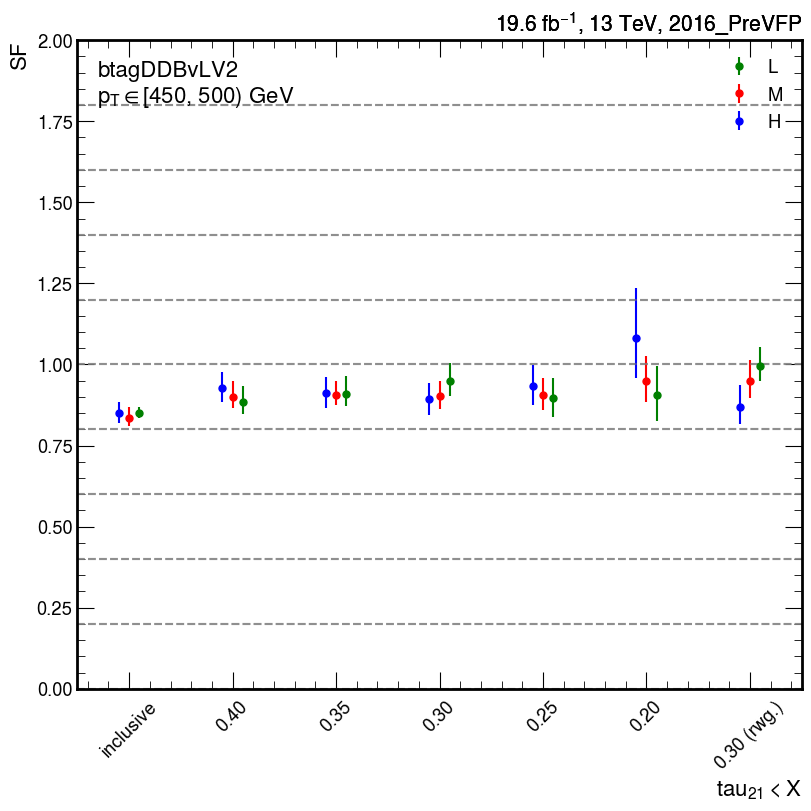

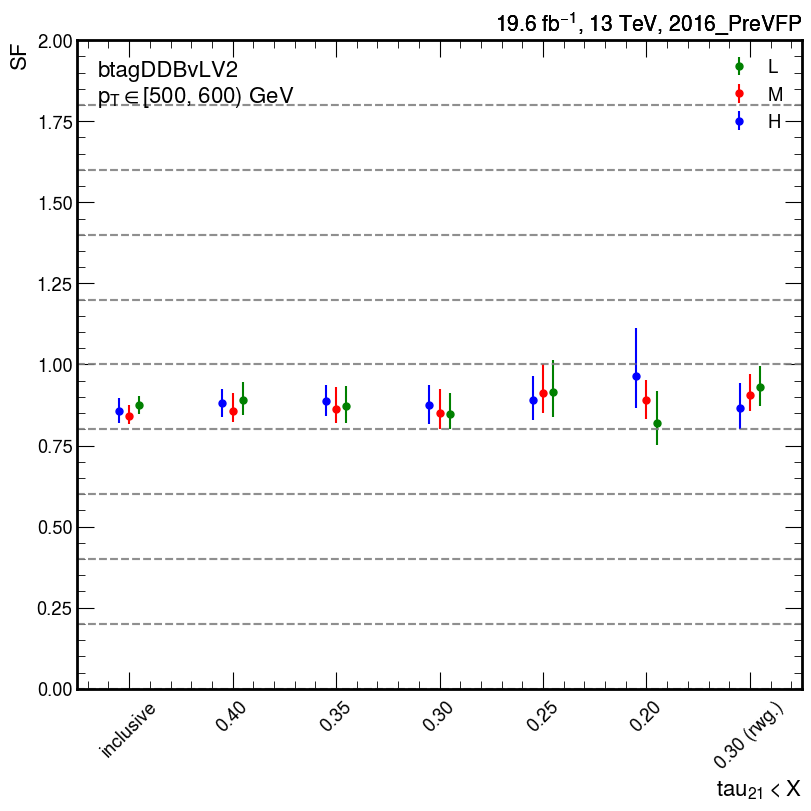

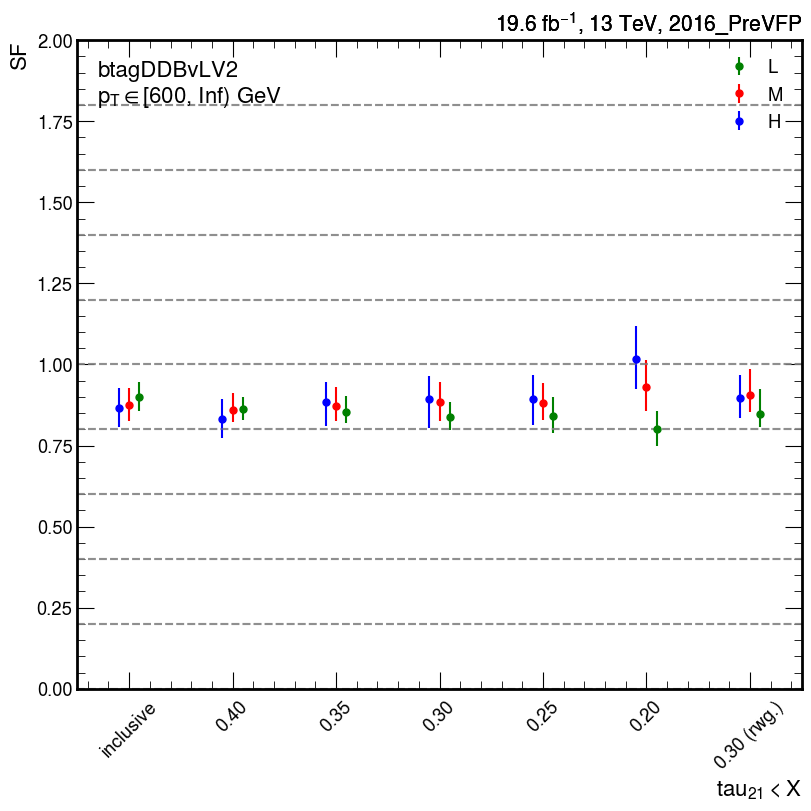

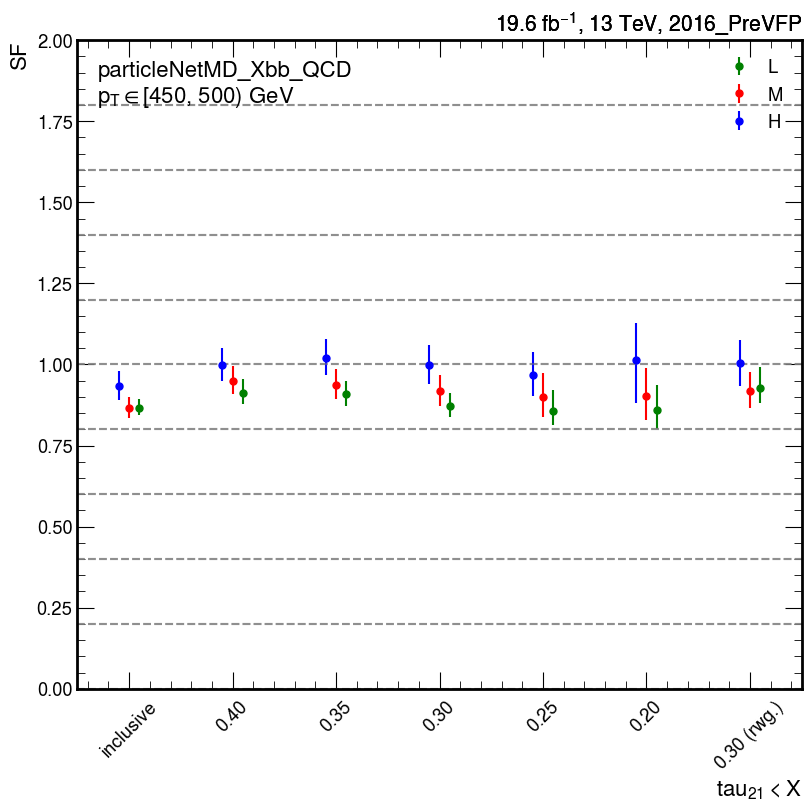

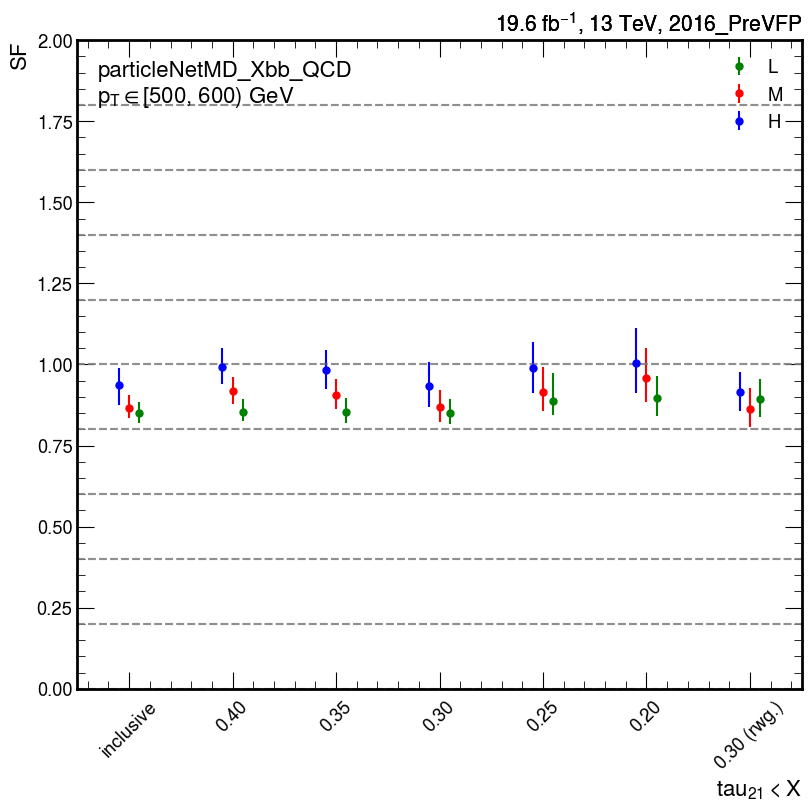

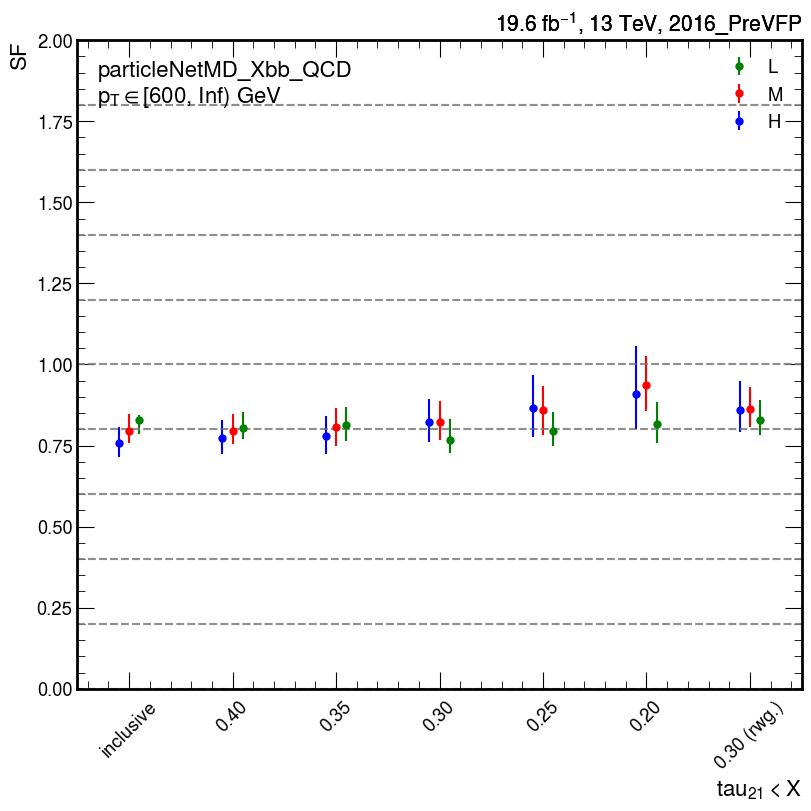

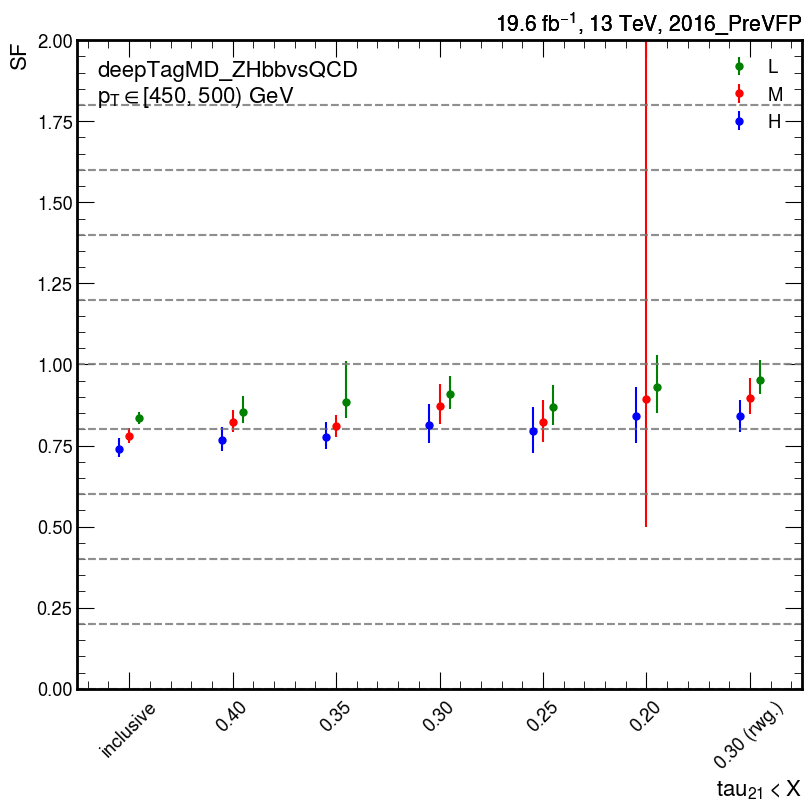

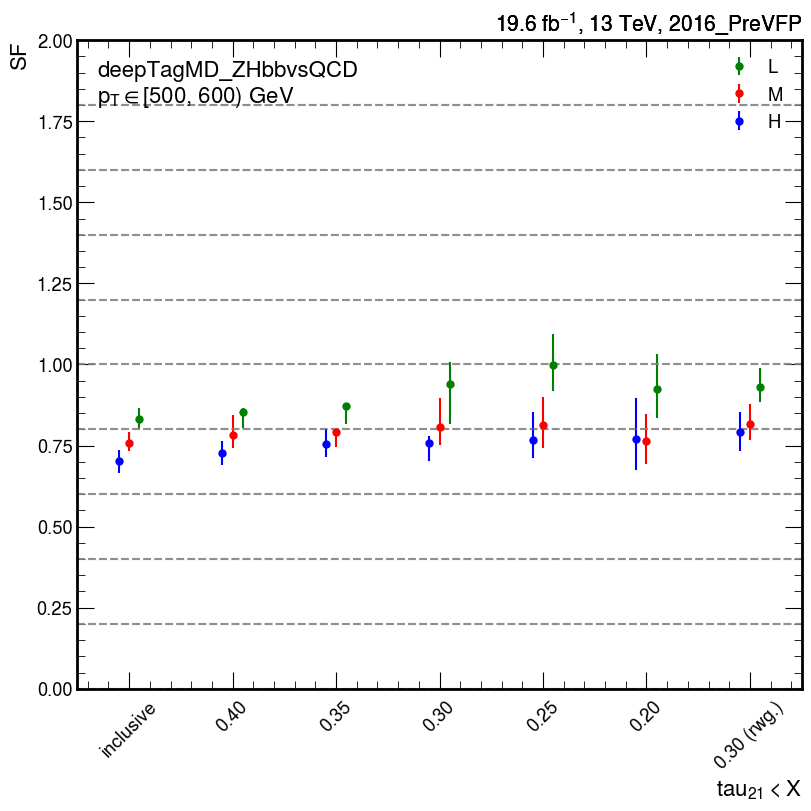

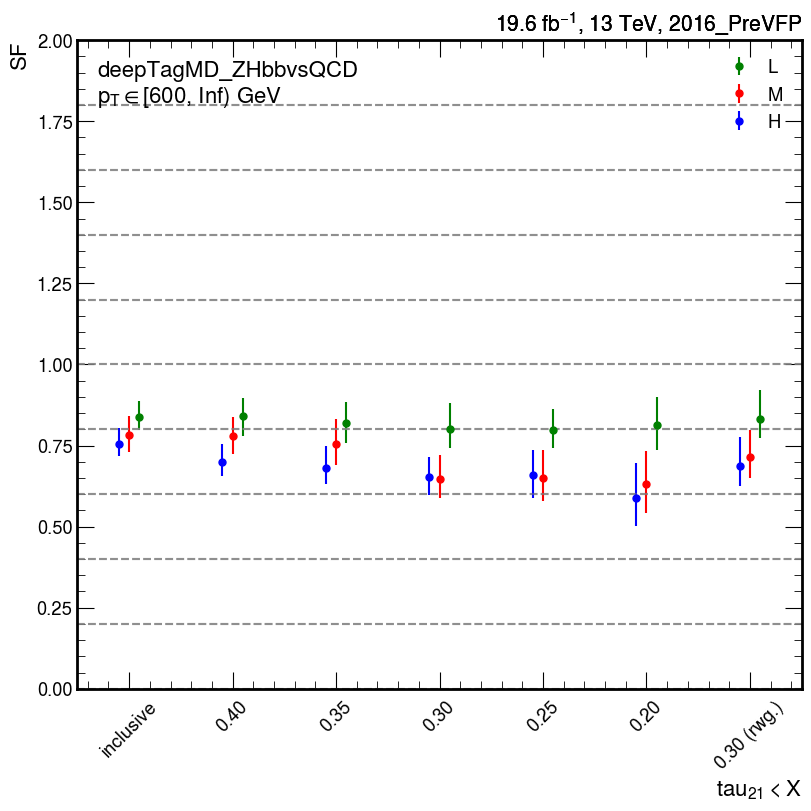

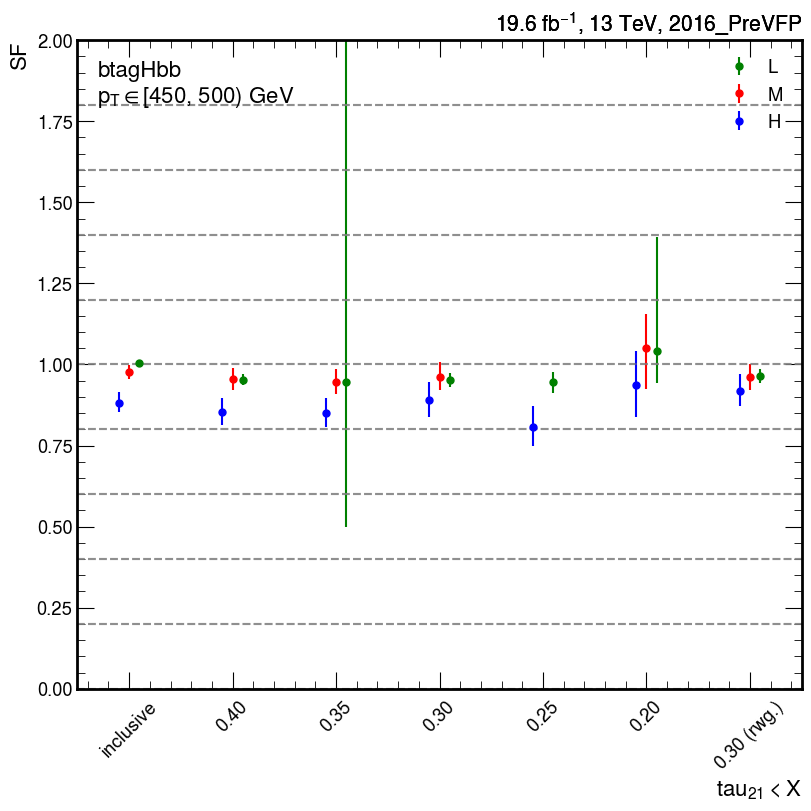

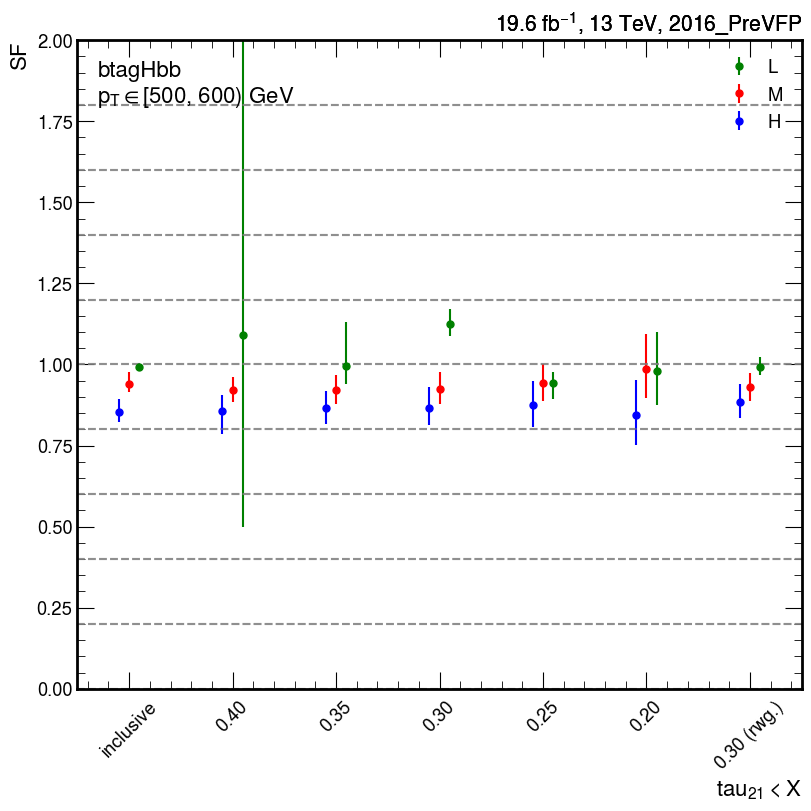

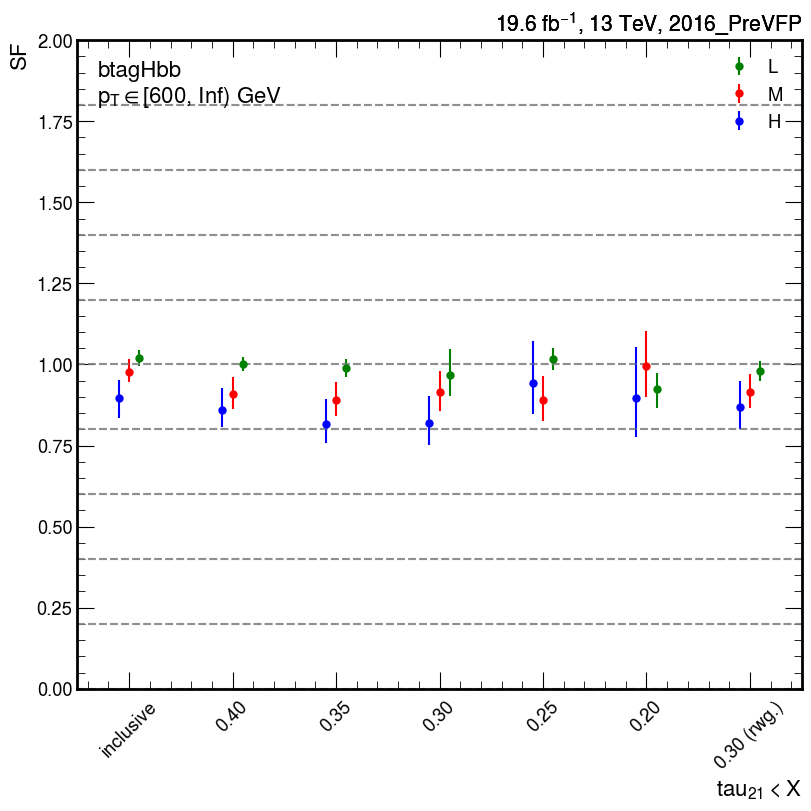

In [12]:
for tagger in AK8Taggers_bb:
    #f, axs = plt.subplots(3,3,figsize=(10,10), constrained_layout=True, dpi=100)
    #plt.subplots_adjust(wspace=0.2, hspace=0.2)
    for iy, pt in enumerate(pts):
        f, ax = plt.subplots(1,1,figsize=(8,8), constrained_layout=True, dpi=100)
        #f.suptitle(tagger, fontsize=16)
        text = tagger +'\n$p_T\in$['+', '.join(pt.split("to"))+') GeV'
        at = AnchoredText(text, loc='upper left', prop={'fontsize' : fontsize}, frameon=False)
        ax.add_artist(at)
        for ix, wp in enumerate(wps):
            sfdata = sf_results[(sf_results.SF_flavour=="b")&\
                                (sf_results.tagger==tagger)&\
                                (sf_results.wp==wp)&\
                                (sf_results.pt==pt)]
            
            sf_max = sfdata[sfdata.tau21!=1].SF.max()
            sf_min = sfdata[sfdata.tau21!=1].SF.min()
            
            indices_x = np.arange(7)
            mask_points = []
            xticklabels = np.array(["inclusive"] + tau21s + ["0.30 (rwg.)"])
            if len(sfdata)<7:
                print("missing fit")
                #continue
                for j, tau21 in enumerate([1] + tau21s):
                    if len(sfdata[sfdata.tau21 == tau21]) == 0:
                        mask_points.append(j)
                if len(sfdata[(sfdata.tau21 == "0.30")&\
                              (sfdata.reweighed == 1)]) == 0:
                    mask_points.append(6)
                indices_new = []
                xticklabels_new = []
                for k in indices_x:
                    if not k in mask_points:
                        indices_new.append(k)
                indices_x = np.array(indices_new)
                xticklabels = xticklabels[indices_x]

            if not 6 in mask_points:
                sf_rew = sfdata[sfdata.reweighed==1].SF.values[0]
                sf_rew_unc = abs(sfdata[sfdata.tau21=="0.30"].SF.values[0] - sf_rew)
            else:
                sf_rew_unc = 0.0
            sf_unc_max = max(abs(sfdata[sfdata.tau21=="0.30"].SF.values[0] - sfdata.SF.values))
            
            results_tau21_uncertainty.append({
                            "SF_flavour": "b",
                            "tagger": tagger,
                            "wp": wp,
                            "pt": pt,
                            "SF": sfdata[sfdata.tau21=="0.30"].SF.values[0],
                            "SF_errUp": sfdata[sfdata.tau21=="0.30"]["SF_errUp"].values[0],
                            "SF_errDown": sfdata[sfdata.tau21=="0.30"]["SF_errDown"].values[0],
                            "tau21_uncertainty": abs(sf_max-sf_min)/2,
                            "tau21_uncertainty_max": sf_unc_max,
                            "reweighting_uncertainty": sf_rew_unc,
                            })
            
            #ax = axs[ix, iy]
            #ax.set_title(f"Pt: {pt}")
            ax.set_xlabel("$tau_{21}< X$")
            ax.set_ylabel("SF")
            #print(np.arange(5), sfdata.SF)
            #try:
            ax.errorbar(indices_x + offset[wp], sfdata.SF.values, yerr=[sfdata.SF_errDown.values, abs(sfdata.SF_errUp.values)],
                        color=colors[ix], linestyle='', marker='o', markersize=5, label=wp)
            #except:
            #    print(indices_x)
            #    print(sfdata.SF.values)
            #    print(sfdata)
            ax.hlines(np.arange(0, 2.2, 0.2), -0.5, 6.5, linestyle='dashed', color='gray', alpha=0.5)
            ax.set_xlim(-0.5, 6.5)
            ax.set_ylim(0.0, 2.0)
            hep.cms.lumitext(text=f'{femtobarn(lumi[year]["tot"], 1)}' + r' fb$^{-1}$, 13 TeV,' + f' {year}', fontsize=fontsize, ax=ax)
            
            ax.set_xticks(indices_x, xticklabels, rotation=45)
            ax.legend()
            
            #ax.plot([1., 6.], [sf_max,sf_max], "b-")
            #ax.plot([1., 6.], [sf_min,sf_min], "b-")
        plt.savefig(f"results_{year}_{tagger}_Pt-{pt}.png", dpi=300, format="png")

missing fit


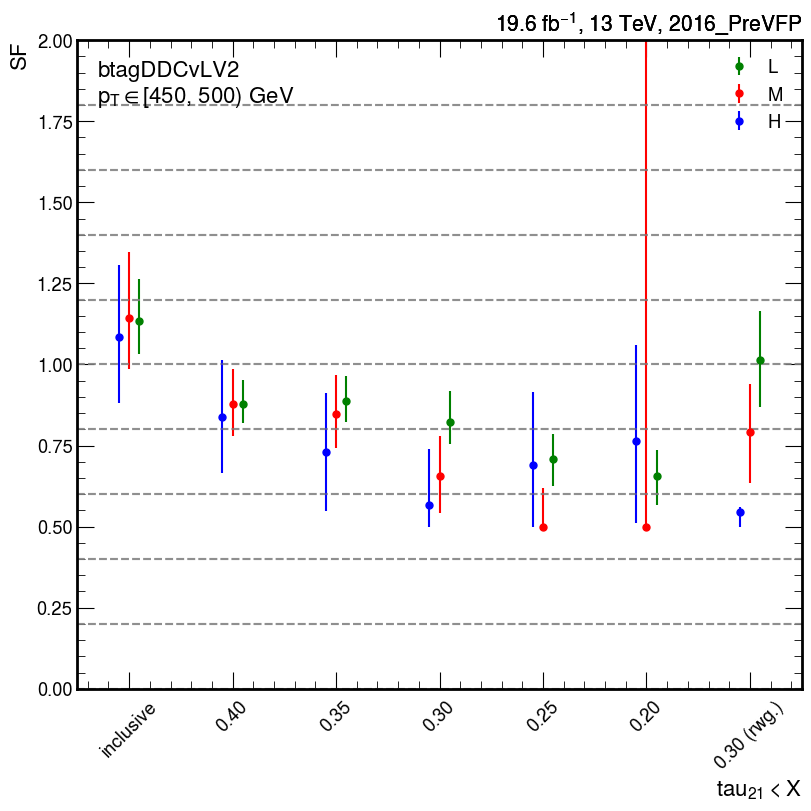

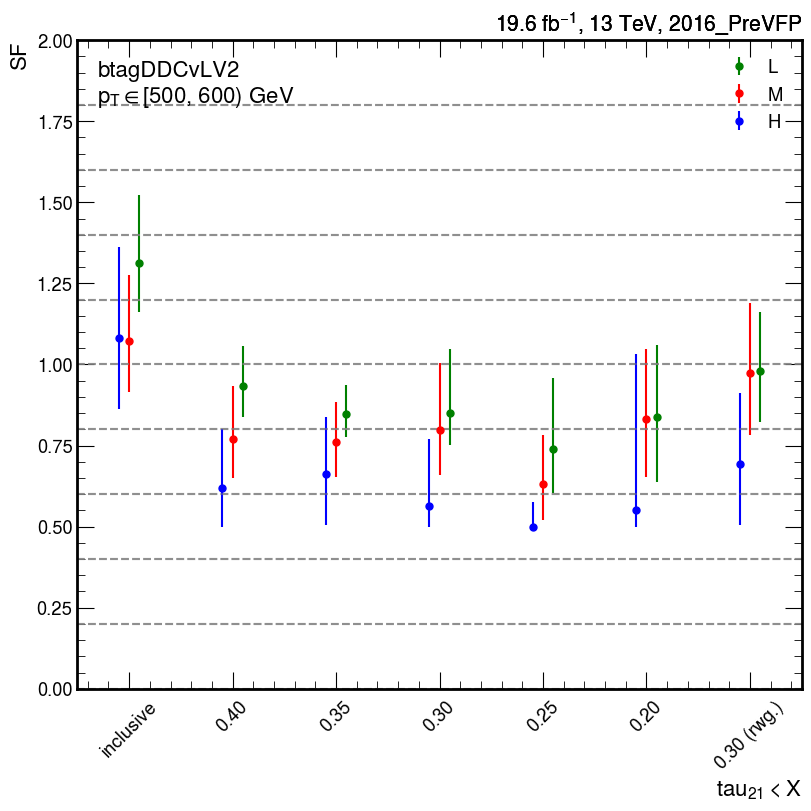

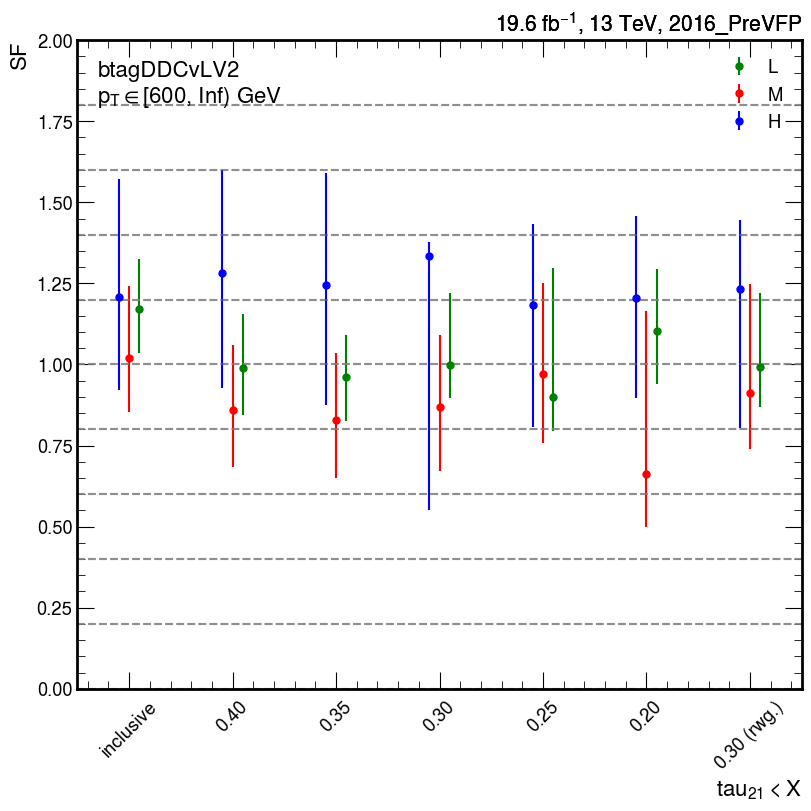

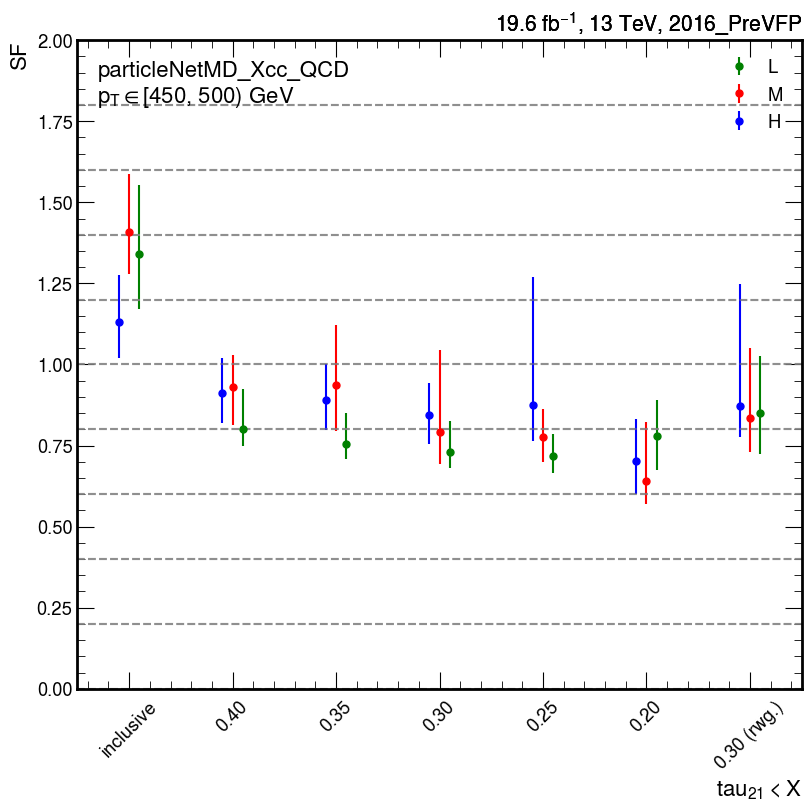

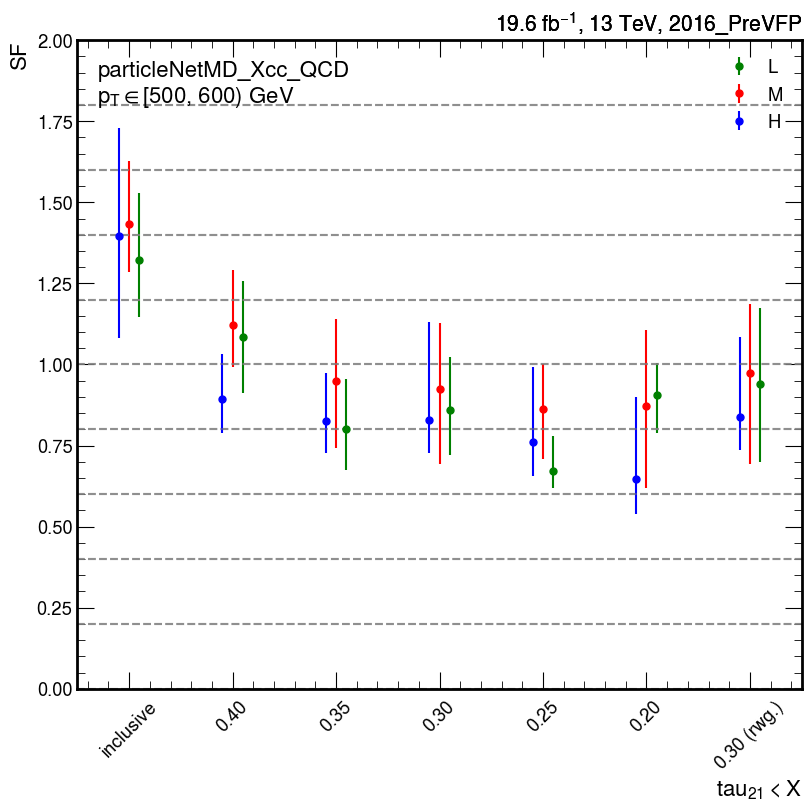

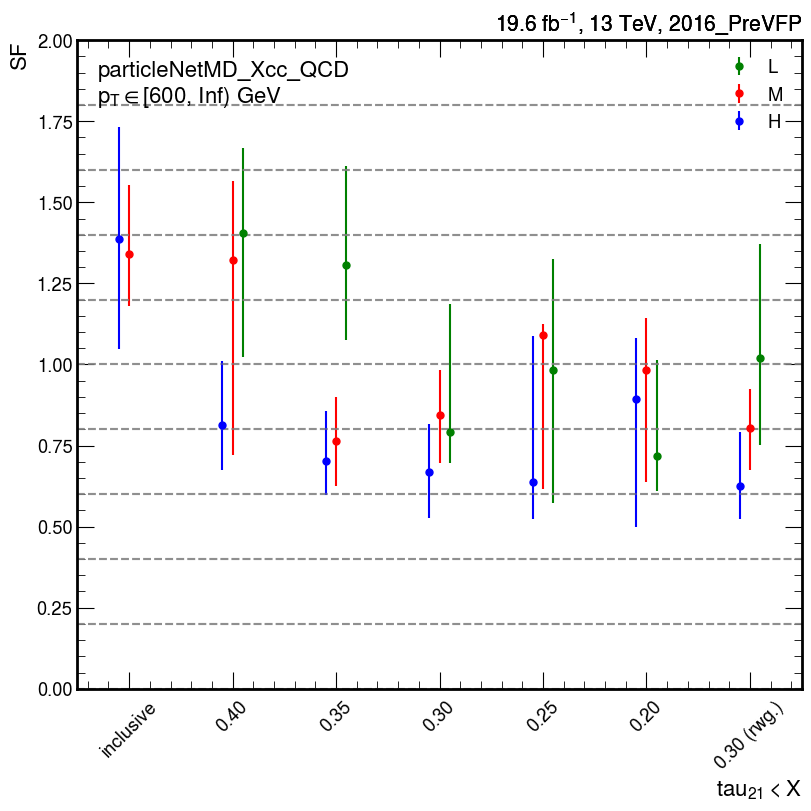

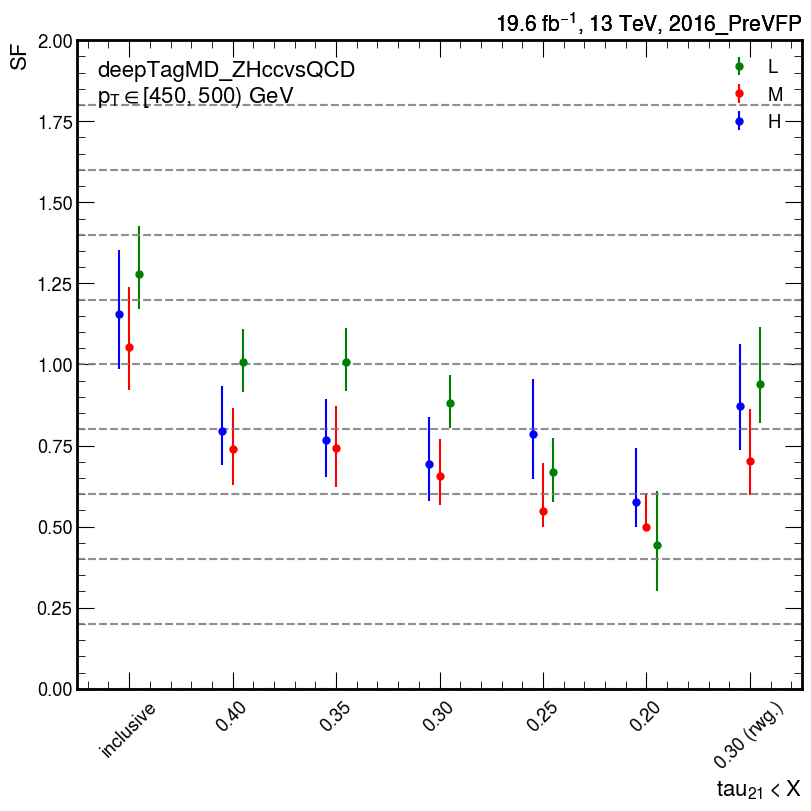

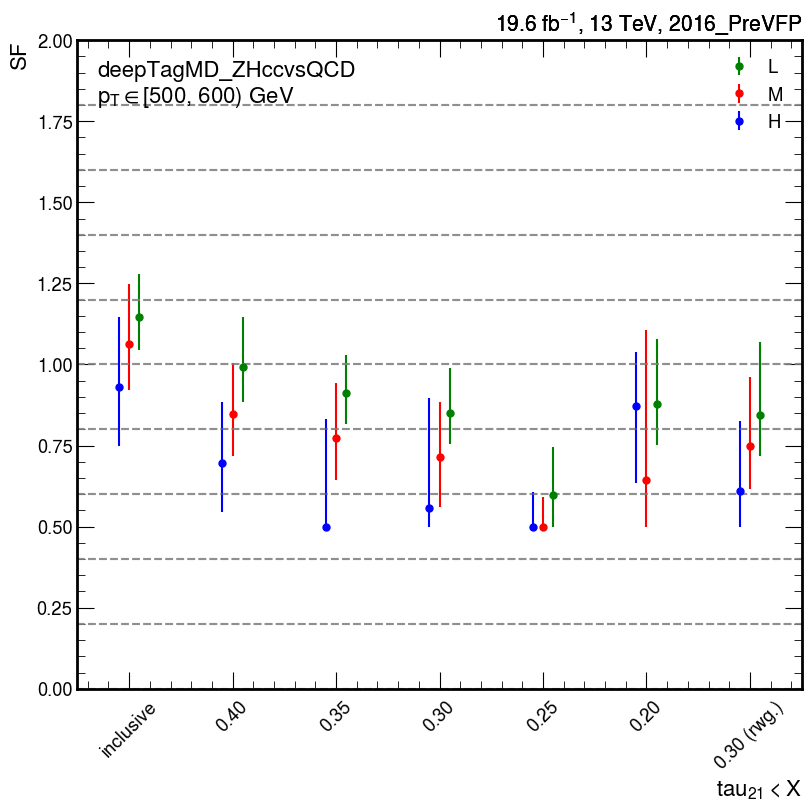

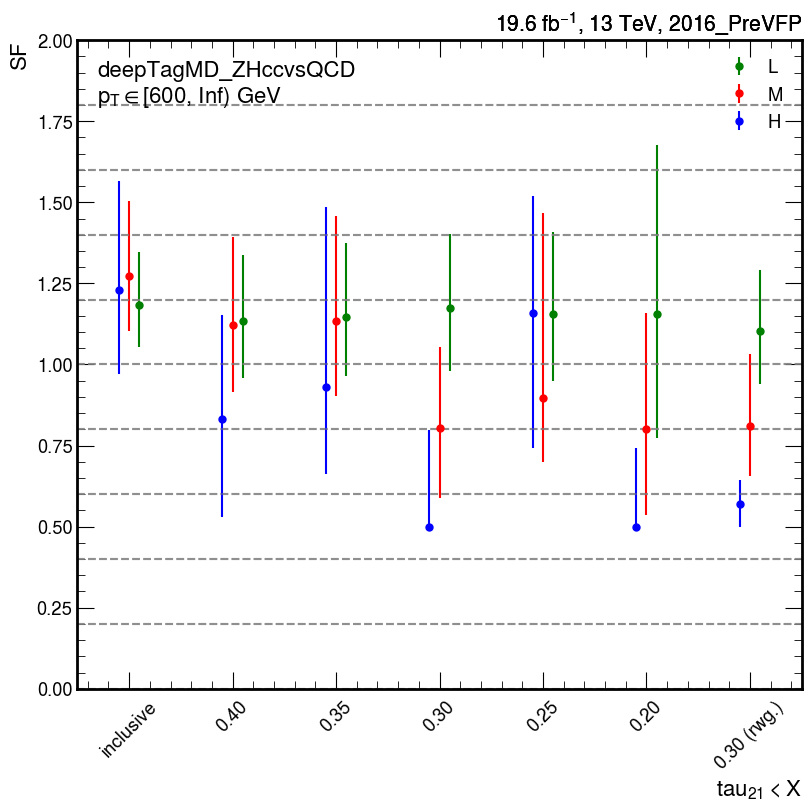

In [13]:
for tagger in AK8Taggers_cc:
    #f, axs = plt.subplots(3,3,figsize=(10,10), constrained_layout=True, dpi=100)
    #plt.subplots_adjust(wspace=0.2, hspace=0.2)
    for iy, pt in enumerate(pts):
        f, ax = plt.subplots(1,1,figsize=(8,8), constrained_layout=True, dpi=100)
        #f.suptitle(tagger, fontsize=16)
        text = tagger +'\n$p_T\in$['+', '.join(pt.split("to"))+') GeV'
        at = AnchoredText(text, loc='upper left', prop={'fontsize' : fontsize}, frameon=False)
        ax.add_artist(at)
        for ix, wp in enumerate(wps):
            sfdata = sf_results[(sf_results.SF_flavour=="c")&\
                                (sf_results.tagger==tagger)&\
                                (sf_results.wp==wp)&\
                                (sf_results.pt==pt)]
            
            sf_max = sfdata[sfdata.tau21!=1].SF.max()
            sf_min = sfdata[sfdata.tau21!=1].SF.min()
            
            indices_x = np.arange(7)
            mask_points = []
            xticklabels = np.array(["inclusive"] + tau21s + ["0.30 (rwg.)"])
            if len(sfdata)<7:
                print("missing fit")
                #continue
                for j, tau21 in enumerate([1] + tau21s):
                    if len(sfdata[sfdata.tau21 == tau21]) == 0:
                        mask_points.append(j)
                if len(sfdata[(sfdata.tau21 == "0.30")&\
                              (sfdata.reweighed == 1)]) == 0:
                    mask_points.append(6)
                indices_new = []
                xticklabels_new = []
                for k in indices_x:
                    if not k in mask_points:
                        indices_new.append(k)
                indices_x = np.array(indices_new)
                xticklabels = xticklabels[indices_x]

            sf_rew = sfdata[sfdata.reweighed==1].SF.values[0]
            sf_rew_unc = abs(sfdata[sfdata.tau21=="0.30"].SF.values[0] - sf_rew)
            sf_unc_max = max(abs(sfdata[sfdata.tau21=="0.30"].SF.values[0] - sfdata.SF.values))
                
            results_tau21_uncertainty.append({
                            "SF_flavour": "c",
                            "tagger": tagger,
                            "wp": wp,
                            "pt": pt,
                            "SF": sfdata[sfdata.tau21=="0.30"].SF.values[0],
                            "SF_errUp": sfdata[sfdata.tau21=="0.30"]["SF_errUp"].values[0],
                            "SF_errDown": sfdata[sfdata.tau21=="0.30"]["SF_errDown"].values[0],
                            "tau21_uncertainty": abs(sf_max-sf_min)/2,
                            "tau21_uncertainty_max": sf_unc_max,
                            "reweighting_uncertainty": sf_rew_unc,
                            })
            
            #ax = axs[ix, iy]
            #ax.set_title(f"Pt: {pt}")
            ax.set_xlabel("$tau_{21}< X$")
            ax.set_ylabel("SF")
            #print(np.arange(5), sfdata.SF)
            #try:
            ax.errorbar(indices_x + offset[wp], sfdata.SF.values, yerr=[sfdata.SF_errDown.values, abs(sfdata.SF_errUp.values)],
                        color=colors[ix], linestyle='', marker='o', markersize=5, label=wp)
            #except:
            #    print(indices_x)
            #    print(sfdata.SF.values)
            #    print(sfdata)
            ax.hlines(np.arange(0, 2.2, 0.2), -0.5, 6.5, linestyle='dashed', color='gray', alpha=0.5)
            ax.set_xlim(-0.5, 6.5)
            ax.set_ylim(0.0, 2.0)
            hep.cms.lumitext(text=f'{femtobarn(lumi[year]["tot"], 1)}' + r' fb$^{-1}$, 13 TeV,' + f' {year}', fontsize=fontsize, ax=ax)
                        
            ax.set_xticks(indices_x, xticklabels, rotation=45)
            ax.legend()
            
            #ax.plot([1., 6.], [sf_max,sf_max], "b-")
            #ax.plot([1., 6.], [sf_min,sf_min], "b-")
        plt.savefig(f"results_{year}_{tagger}_Pt-{pt}.png", dpi=300, format="png")

In [14]:
results_tau21_uncertainty = pd.DataFrame(results_tau21_uncertainty)
results_tau21_uncertainty.to_csv(f"sf_results_{year}.csv", mode='w', header=True)

In [15]:
results_tau21_uncertainty

,SF_flavour,tagger,wp,pt,SF,SF_errUp,SF_errDown,tau21_uncertainty,tau21_uncertainty_max,reweighting_uncertainty
0,b,btagDDBvLV2,L,450to500,0.948710,0.056509,4.453755e-02,0.055747,0.098158,0.045667
1,b,btagDDBvLV2,M,450to500,0.902936,0.045479,3.923686e-02,0.024604,0.067067,0.044758
2,b,btagDDBvLV2,H,450to500,0.892598,0.051262,4.703874e-02,0.107148,0.189485,0.024810
3,b,btagDDBvLV2,L,500to600,0.846610,0.065984,4.626418e-02,0.055256,0.084035,0.084035
4,b,btagDDBvLV2,M,500to600,0.849772,0.075115,4.871784e-02,0.031057,0.062113,0.054589
...,...,...,...,...,...,...,...,...,...,...
58,c,deepTagMD_ZHccvsQCD,M,500to600,0.713079,0.170639,1.511738e-01,0.172976,0.350468,0.033980
59,c,deepTagMD_ZHccvsQCD,H,500to600,0.558003,0.337685,5.799430e-02,0.186599,0.373090,0.052849
60,c,deepTagMD_ZHccvsQCD,L,600toInf,1.175295,0.226925,1.967462e-01,0.036106,0.072213,0.072213
61,c,deepTagMD_ZHccvsQCD,M,600toInf,0.802781,0.250133,2.160749e-01,0.166236,0.469031,0.008168


In [16]:
missing_fits

['/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/2016_PreVFP/fit_inclusive_all_renormalized/results/fitResults_msd40particleNetMD_Xcc_QCDLwp_Pt-600toInf.csv',
 '/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/2016_PreVFP/fit_tau21p25_all_renormalized/results/fitResults_msd40btagHbbMwp_Pt-450to500.csv']

In [17]:
len(missing_fits)

2